In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.colors as mcolors
import json
from skimage.draw import line

import geo_utils as gu

In [3]:
print(f"Bounding box in UTM: ({gu._xmin}, {gu._ymin}) to ({gu._xmax}, {gu._ymax})")
print(f"Top Left:\t({gu.LAT_MIN}, {gu.LON_MIN})\nBottom Right:\t({gu.LAT_MAX}, {gu.LON_MAX})")
print(f"Aspect Ratio (meters): {gu.HEIGHT_METERS/gu.WIDTH_METERS}, Aspect Ratio (pixels): {gu.HEIGHT_PX/gu.WIDTH_PX}")
print(f"Spray Radius: {gu.SPRAY_RADIUS}")

Bounding box in UTM: (489041.0228945217, 1805088.1163430738) to (489151.6696408869, 1804873.5769851631)
Top Left:	(16.326805747535087, 80.89740320760403)
Bottom Right:	(16.32486678659248, 80.89844007039832)
Aspect Ratio (meters): 1.9365858988861402, Aspect Ratio (pixels): 1.9389576734811402
Spray Radius: 5


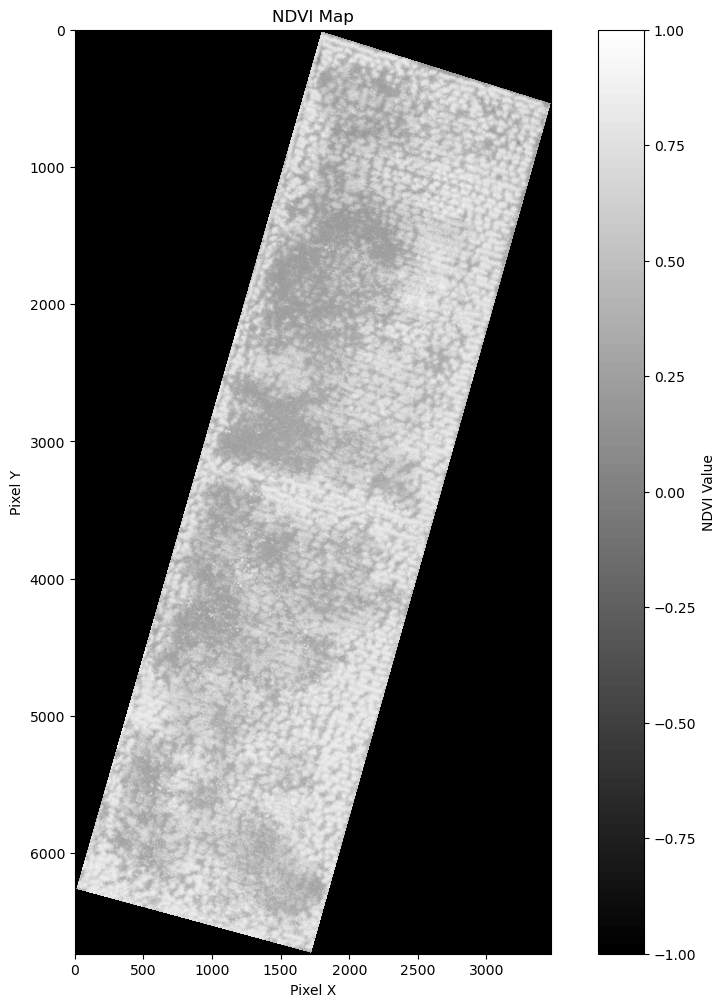

In [4]:
colors = [(0,0,0), (1,1,1)]
n_bins = 100
cmap = LinearSegmentedColormap.from_list("white_black", colors, N=n_bins)
norm = Normalize(vmin=-1, vmax=1)

plt.figure(figsize=(12, 12))
img = plt.imshow(gu.ndvi, cmap=cmap, norm=norm)
plt.colorbar(img, label='NDVI Value')

plt.title('NDVI Map')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')

plt.imshow(np.ma.masked_less(gu.ndvi, -1), cmap=cmap, norm=norm)
plt.show()

In [5]:
infected_chunks = []
cutoffs = {
    "avg": 0.5,
    "mask_ratio": 0.6
}

def is_infected(chunk, thresholds, out_arr=infected_chunks):
    chunk_masked = np.ma.masked_equal(chunk, gu.NDVI_NAN_MASK)

    chunk_mask_ratio = np.count_nonzero(chunk_masked.mask) / chunk.size
    chunk_avg = np.mean(chunk_masked)
    
    if (chunk_mask_ratio < thresholds["mask_ratio"] and chunk_avg < thresholds["avg"]):
        return True
    else:
        return False


for chunk_y in range(len(gu.CHUNK_BOUNDS[0])):
    for chunk_x in range(len(gu.CHUNK_BOUNDS[1])):
        chunk = gu.get_chunk(chunk_y, chunk_x)

        if chunk.size == 0:
            continue

        if is_infected(chunk, cutoffs):
            infected_chunks.append((chunk_y, chunk_x, np.mean(np.ma.masked_equal(chunk, gu.NDVI_NAN_MASK))))

print(f"Total infected chunks: {len(infected_chunks)}")
print(infected_chunks)


Total infected chunks: 140
[(2, 11, 0.44636986), (2, 12, 0.44116595), (2, 13, 0.45137456), (2, 14, 0.3813884), (3, 12, 0.43933982), (3, 13, 0.47453272), (3, 14, 0.44372562), (3, 15, 0.49590093), (4, 12, 0.3513628), (4, 13, 0.34989032), (4, 14, 0.40203515), (4, 15, 0.48251674), (5, 12, 0.44608775), (5, 21, 0.4986963441630275), (6, 11, 0.44507527), (6, 12, 0.4398402), (7, 11, 0.4030305), (7, 12, 0.4328066), (7, 13, 0.45075458), (8, 10, 0.45022276), (8, 11, 0.30669856), (8, 12, 0.3051927), (8, 13, 0.31129286), (8, 14, 0.41920877), (9, 10, 0.45296535), (9, 11, 0.28394386), (9, 12, 0.2737553), (9, 13, 0.2759734), (9, 14, 0.30530897), (10, 9, 0.3881923), (10, 10, 0.26819593), (10, 11, 0.3208207), (10, 12, 0.39354023), (10, 13, 0.40579554), (10, 14, 0.2986111), (10, 15, 0.48025993), (11, 9, 0.27547896), (11, 10, 0.3032391), (11, 11, 0.32378674), (11, 12, 0.41283914), (11, 13, 0.42157513), (11, 14, 0.496007), (12, 9, 0.3112023), (12, 10, 0.31383395), (12, 11, 0.31243527), (12, 12, 0.3691199), 

In [6]:
infected_coords = []

for chunk_y, chunk_x, avg in infected_chunks:
    corners_latlon = gu.chunk_coord_to_geo_coord(chunk_y, chunk_x, y_offset=gu.CHUNK_DIM/2, x_offset=gu.CHUNK_DIM/2)
    
    infected_coords.append({
        "chunk_index": [chunk_y, chunk_x],
        "coordinates": corners_latlon,
        "value": float(avg)
    })

with open("Data/infected.json", "w") as f:
    json.dump(infected_coords, f, indent=4)

print(f"Saved {len(infected_coords)} chunks to infected.json")


Saved 140 chunks to infected.json


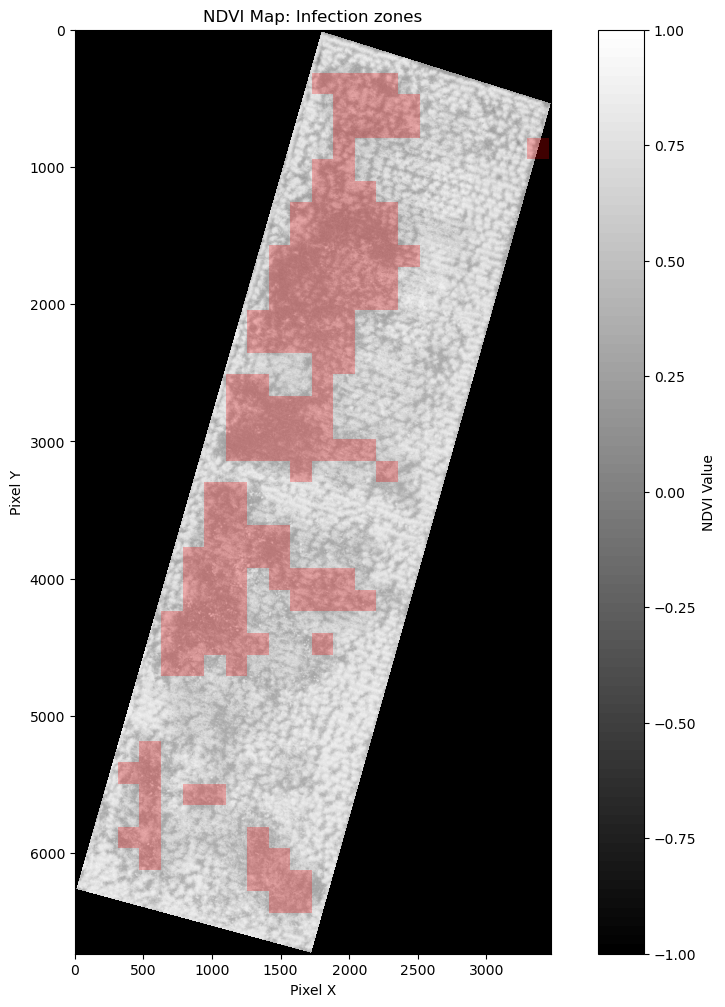

In [7]:
plt.figure(figsize=(12, 12))

img = plt.imshow(gu.ndvi, cmap=cmap, norm=norm)
plt.colorbar(img, label='NDVI Value')
plt.imshow(np.ma.masked_less(gu.ndvi, -1), cmap=cmap, norm=norm)

for chunk_y, chunk_x, infection_level in infected_chunks:
    start_y = chunk_y * gu.CHUNK_DIM
    start_x = chunk_x * gu.CHUNK_DIM
    
    height = min(gu.CHUNK_DIM, gu.ndvi.shape[0] - start_y)
    width = min(gu.CHUNK_DIM, gu.ndvi.shape[1] - start_x)
    
    alpha = 0.25
    
    rect = patches.Rectangle(
        (start_x, start_y),
        width,
        height,
        linewidth=0,
        edgecolor=None,
        facecolor=(1, 0, 0, alpha),
        zorder=3
    )
    
    plt.gca().add_patch(rect)

plt.title('NDVI Map: Infection zones')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')

plt.show()